In [38]:
import os
from pathlib import Path
%pip install python-dotenv
from dotenv import load_dotenv

load_dotenv()


# Grab the secret key without exposing it
api_key = os.getenv("OPENAI_API_KEY")

# Local paths: files are stored in this project folder.
DATA_DIR = Path(".")
CODES_DIR = DATA_DIR / "Codes"
PDF_DIR = DATA_DIR / "PDFs"

# This Mac uses Apple unified memory. Keep model workloads on the CPU.
COMPUTE_DEVICE = "cpu"

# Set OPENAI_API_KEY in your environment before running the notebook.
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    print("OPENAI_API_KEY is not set. Add it to your environment before using OpenAI features.")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

%pip install -q -U datasets accelerate evaluate huggingface_hub


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np

# Load the diabetes dataset from the project directory.
df = pd.read_csv(
    DATA_DIR / 'diabetic_data.csv',
    dtype={"max_glu_serum": "string", "A1Cresult": "string"},
    keep_default_na=False,
)

columns_to_drop = ['weight', 'citoglipton', 'examide']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Count missing values (NaN/None) and '?' entries by column.
missing_nan = df.isna().sum()
question_mark_counts = (df == '?').sum()
missing_counts = pd.DataFrame({
    'NaN/None_count': missing_nan,
    'Question_mark_count': question_mark_counts,
})
missing_counts['Total_missing'] = missing_counts['NaN/None_count'] + missing_counts['Question_mark_count']
missing_with_values = missing_counts[missing_counts['Total_missing'] > 0].sort_values('Total_missing', ascending=False)

print("\n=== MISSING VALUE SUMMARY ===")
print("\nColumns with missing values:")
print(missing_with_values)
print(f"\n\nTotal missing values in dataset: {missing_counts['Total_missing'].sum()}")
print("\nAll columns summary:")
print(missing_counts.sort_values('Total_missing', ascending=False))

if 'medical_specialty' in df.columns:
    df['medical_specialty'] = df['medical_specialty'].replace('?', 'no specialty')
    print("\nFilled '?' in medical_specialty with 'no specialty'")

# Replace question marks in diagnosis columns with "none".
for col in ['diag_1', 'diag_2', 'diag_3']:
    if col in df.columns:
        df[col] = df[col].replace('?', 'none')
        print(f"Replaced '?' with 'none' in {col}")

print(f"Dataset shape: {df.shape}")
print(df.head())

# Convert '>30' to 'NO' in the readmission target.
df['readmitted'] = df['readmitted'].replace('>30', 'NO')
print("\nUpdated 'readmitted' column in df:")
display(df['readmitted'].value_counts())


=== MISSING VALUE SUMMARY ===

Columns with missing values:
                   NaN/None_count  Question_mark_count  Total_missing
medical_specialty               0              49949.0        49949.0
payer_code                      0              40256.0        40256.0
race                            0               2273.0         2273.0
diag_3                          0               1423.0         1423.0
diag_2                          0                358.0          358.0
diag_1                          0                 21.0           21.0


Total missing values in dataset: 94280.0

All columns summary:
                          NaN/None_count  Question_mark_count  Total_missing
medical_specialty                      0              49949.0        49949.0
payer_code                             0              40256.0        40256.0
race                                   0               2273.0         2273.0
diag_3                                 0               1423.0         1423.0

readmitted
NO     90409
<30    11357
Name: count, dtype: int64

simple logistic regression for analysis (taken from Quant Proj)


In [5]:
# @title

#load packages sklearn, pandas, numpy, matlab
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Plotting
import matplotlib.pyplot as plt

#load data
raw_data = df
raw_data.head()
display(raw_data.dtypes)
display(raw_data["A1Cresult"].head(50))
display(raw_data["max_glu_serum"].head(50))
display(raw_data["A1Cresult"].unique())
display(raw_data["max_glu_serum"].unique())
display(raw_data.dtypes)


encounter_id                 int64
patient_nbr                  int64
race                           str
gender                         str
age                            str
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                     str
medical_specialty              str
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                         str
diag_2                         str
diag_3                         str
number_diagnoses             int64
max_glu_serum               string
A1Cresult                   string
metformin                      str
repaglinide                    str
nateglinide                    str
chlorpropamide                 str
glimepiride                    str
acetohexamide       

0     None
1     None
2     None
3     None
4     None
5     None
6     None
7     None
8     None
9     None
10    None
11    None
12    None
13    None
14    None
15    None
16    None
17    None
18    None
19    None
20    None
21    None
22    None
23    None
24    None
25    None
26      >7
27    None
28    None
29    None
30    None
31    None
32    None
33    None
34    None
35    None
36    None
37    None
38    None
39    None
40    None
41    None
42    None
43    None
44    None
45    None
46    None
47    None
48    None
49    None
Name: A1Cresult, dtype: string

0     None
1     None
2     None
3     None
4     None
5     None
6     None
7     None
8     None
9     None
10    None
11    None
12    None
13    None
14    None
15    None
16    None
17    None
18    None
19    None
20    None
21    None
22    None
23    None
24    None
25    None
26    None
27    None
28    None
29    None
30    None
31    None
32    None
33    None
34    None
35    None
36    None
37    None
38    None
39    None
40    None
41    None
42    None
43    None
44    None
45    None
46    None
47    None
48    None
49    None
Name: max_glu_serum, dtype: string

<ArrowStringArray>
['None', '>7', '>8', 'Norm']
Length: 4, dtype: string

<ArrowStringArray>
['None', '>300', 'Norm', '>200']
Length: 4, dtype: string

encounter_id                 int64
patient_nbr                  int64
race                           str
gender                         str
age                            str
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                     str
medical_specialty              str
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                         str
diag_2                         str
diag_3                         str
number_diagnoses             int64
max_glu_serum               string
A1Cresult                   string
metformin                      str
repaglinide                    str
nateglinide                    str
chlorpropamide                 str
glimepiride                    str
acetohexamide       

In [6]:
# @title
cat_cols = [
    'race', 'gender', 'payer_code', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'age', 'medical_specialty', 'max_glu_serum', 'A1Cresult',
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone',
    'change', 'diabetesMed', 'diag_1', 'diag_2', 'diag_3'
]

for col in cat_cols:
    # Check if the column still exists in df before attempting to get dummies
    if col in df.columns:
        dummies = pd.get_dummies(df[col], prefix=col)
        df = pd.concat([df, dummies], axis=1)
        df = df.drop(columns=[col])
    else:
        print(f"Warning: Column '{col}' not found in DataFrame 'df'. Skipping one-hot encoding.")

In [7]:
ID_COL = "patient_nbr"
LABEL_COL = "readmitted"

FEATURE_COLS = [col for col in df.columns if col not in [ID_COL, LABEL_COL]]
print(f"Updated FEATURE_COLS with {len(FEATURE_COLS)} features.")
# Display some of the new feature columns for verification
print(FEATURE_COLS[:5])
print(FEATURE_COLS[-5:])

Updated FEATURE_COLS with 2507 features.
['encounter_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications']
['diag_3_V70', 'diag_3_V72', 'diag_3_V85', 'diag_3_V86', 'diag_3_none']


In [8]:
# @title
#Encoding
for index, row in df.iterrows():
    print(row)
    break

encounter_id          2278392
patient_nbr           8222157
time_in_hospital            1
num_lab_procedures         41
num_procedures              0
                       ...   
diag_3_V70              False
diag_3_V72              False
diag_3_V85              False
diag_3_V86              False
diag_3_none              True
Name: 0, Length: 2509, dtype: object


In [9]:
# @title
#logistic regression
#make sure only binary 30 day or no is being predicted.
#from sklearn.linear_model import LogisticRegression

#my_model.fit(train_diab_data.drop(["readmitted"], axis=1), train_diab_data["readmitted"])
#from sklearn.linear_model import LogisticRegressionCV

#my_model = LogisticRegressionCV(
#    cv=5,
#    max_iter=500,
#    scoring="accuracy",
#    solver="lbfgs",
#    class_weight='balanced'
#)

#X = df.drop("readmitted", axis=1)
#y = df["readmitted"]

#my_model.fit(X, y)

#print("done")

#display(my_model.score(X,y))

In [ ]:
# @title
#output predicted logistic regression probabilities for each patient
#y_pred_proba_lr = my_model.predict_proba(X)

# Get class names from the model to label columns correctly
#class_names = my_model.classes_

# Create a DataFrame for probabilities
#proba_df = pd.DataFrame(y_pred_proba_lr, columns=[f'probability_{cls}' for cls in class_names])

# Add the patient_nbr (ID_COL) to this DataFrame
# Ensure X is reset_index to align with proba_df if X has a non-default index
#proba_df[ID_COL] = X[ID_COL].reset_index(drop=True)

# Display the first few rows of the DataFrame
#display(proba_df.head())

In [ ]:
# @title
# Get feature importances (coefficients) from the logistic regression model
#feature_importance = pd.DataFrame({
#    'feature': X.columns,
#    'coefficient': my_model.coef_[0] # Assuming binary classification, get the first class's coefficients
#})

# Sort by absolute coefficient value to see most important features
#feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()
#feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)

#print("\nTop 10 most important features (by absolute coefficient value):")
#display(feature_importance.head(10))

#print("\nTop 10 least important features (by absolute coefficient value):")
#display(feature_importance.tail(10))

In [ ]:
# Export feature importance to the local project directory when needed.
# feature_importance.to_excel(DATA_DIR / 'feature_importance.xlsx', index=False)

In [ ]:
# @title
#take top 50 most impactful features
#top_50_features = feature_importance.head(50)
#rerun logistic regression with top 50 features
#X = df[top_50_features['feature']]
#y = df["readmitted"]

#my_model.fit(X, y)

#print("done")

#display(my_model.score(X,y))

In [ ]:
# @title
#take top 25 most impactful features
#top_25_features = feature_importance.head(25)
#rerun logistic regression with top 50 features
#X = df[top_25_features['feature']]
#y = df["readmitted"]

#my_model.fit(X, y)

#print("done")

#display(my_model.score(X,y))


In [14]:
# @title
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import numpy as np # Ensure numpy is imported for np.where

# Define X and y using the top 25 features
#X_top25 = df[top_25_features['feature']]
#y_top25 = df["readmitted"]

# Perform 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_top25, y_top25, test_size=0.2, random_state=42, stratify=y_top25
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Re-train the logistic regression model (my_model) with the training data
my_model.fit(X_train, y_train)

print("Logistic Regression model re-trained with top 25 features on training data.")

# Evaluate the model on the hold-out test set
y_pred_test = my_model.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test, pos_label='<30') # Calculate F1 Score

# Get probabilities for AUC calculation
y_pred_proba_test = my_model.predict_proba(X_test)

# Find the index of the positive class ('<30') in my_model.classes_
pos_class_idx = np.where(my_model.classes_ == '<30')[0][0]

# Convert y_test to numerical labels for AUC calculation
# Map the positive class ('<30') to 1 and the negative class ('NO') to 0
y_test_numeric_for_auc = y_test.apply(lambda x: 1 if x == '<30' else 0)

# Calculate AUC without the pos_label argument, as y_test_numeric_for_auc is now binary
auc_test = roc_auc_score(y_test_numeric_for_auc, y_pred_proba_test[:, pos_class_idx])

print(f"\nModel accuracy on the 20% hold-out test set: {accuracy_test:.4f}")
print(f"Model F1 Score on the 20% hold-out test set: {f1_test:.4f}")
print(f"Model AUC on the 20% hold-out test set: {auc_test:.4f}")

NameError: name 'X_top25' is not defined

In [ ]:
#add in a weighted model to account for the difference between the cost of a false negative is $15,000, and a true negative and false postive which is a cost of $1000


### Cost Analysis for Logistic Regression Model

To account for the financial implications of different prediction outcomes, we will define a cost matrix:

*   **False Negative (Actual <30, Predicted NO):** Cost = $15,000 (a patient is readmitted within 30 days but predicted not to be)
*   **True Negative (Actual NO, Predicted NO):** Cost = $1,000 (a patient is not readmitted and predicted not to be)
*   **False Positive (Actual NO, Predicted <30):** Cost = $1,000 (a patient is not readmitted but predicted to be)
*   **True Positive (Actual <30, Predicted <30):** Cost = $0 (a patient is readmitted and predicted to be, allowing for timely intervention)

In [15]:
# @title
from sklearn.metrics import confusion_matrix

# Define the costs
COST_FALSE_NEGATIVE = 15000
COST_TRUE_NEGATIVE = 0 #no and actual no is not additional cost.
COST_FALSE_POSITIVE = 1000
COST_TRUE_POSITIVE = 1000

# Get the class labels from the fitted model
# Assuming '<30' is the positive class (index 1) and 'NO' is the negative class (index 0)
class_labels_ordered = ['NO', '<30'] # Make sure this order matches the confusion matrix output

# Calculate the confusion matrix for the test set (using y_test and y_pred_test from EDts9b3fbqUv)
# Ensure y_test and y_pred_test are still available from previous cell execution
cm = confusion_matrix(y_test, y_pred_test, labels=class_labels_ordered)

# Extract TN, FP, FN, TP from the confusion matrix
# If labels are ['NO', '<30']:
# cm = [[TN, FP],
#       [FN, TP]]

TN = cm[0, 0] # Actual NO, Predicted NO
FP = cm[0, 1] # Actual NO, Predicted <30
FN = cm[1, 0] # Actual <30, Predicted NO
TP = cm[1, 1] # Actual <30, Predicted <30

# Calculate total cost
total_cost = (TN * COST_TRUE_NEGATIVE) + \
             (FP * COST_FALSE_POSITIVE) + \
             (FN * COST_FALSE_NEGATIVE) + \
             (TP * COST_TRUE_POSITIVE)

print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives (Actual NO, Predicted NO): {TN}")
print(f"False Positives (Actual NO, Predicted <30): {FP}")
print(f"False Negatives (Actual <30, Predicted NO): {FN}")
print(f"True Positives (Actual <30, Predicted <30): {TP}")
print(f"\nTotal Cost (considering specified weights): ${total_cost:,}")

NameError: name 'y_test' is not defined

In [ ]:
# @title
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import numpy as np

# Define the class weights to penalize false negatives more heavily
# The positive class ('<30') will receive a higher weight.
# The cost for false negative (15000) is 15 times the cost of false positive (1000)
# So, we can set the weight for the positive class to be 15 times higher.
class_weights = {'NO': 1, '<30': 15}

print(f"Using class weights: {class_weights}")

# Re-initialize the Logistic Regression model with class weights
weighted_model = LogisticRegressionCV(
    cv=5,
    max_iter=500,
    scoring="accuracy", # Scoring still based on accuracy for CV, but weights apply to loss function
    solver="lbfgs",
    class_weight=class_weights # Apply the defined class weights
)

# Retrain the weighted model using the top 25 features (X_top25, y_top25)
# Perform 80/20 train-test split again for consistency
X_train_weighted, X_test_weighted, y_train_weighted, y_test_weighted = train_test_split(
    X_top25, y_top25, test_size=0.2, random_state=42, stratify=y_top25
)

weighted_model.fit(X_train_weighted, y_train_weighted)

print("Weighted Logistic Regression model trained with top 25 features on training data.")

# Evaluate the weighted model on the hold-out test set
y_pred_test_weighted = weighted_model.predict(X_test_weighted)
accuracy_test_weighted = accuracy_score(y_test_weighted, y_pred_test_weighted)
f1_test_weighted = f1_score(y_test_weighted, y_pred_test_weighted, pos_label='<30')

# Get probabilities for AUC calculation for the weighted model
y_pred_proba_test_weighted = weighted_model.predict_proba(X_test_weighted)

# Find the index of the positive class ('<30') in weighted_model.classes_
pos_class_idx_weighted = np.where(weighted_model.classes_ == '<30')[0][0]

# Convert y_test_weighted to numerical labels for AUC calculation
y_test_numeric_for_auc_weighted = y_test_weighted.apply(lambda x: 1 if x == '<30' else 0)

# Calculate AUC for the weighted model
auc_test_weighted = roc_auc_score(y_test_numeric_for_auc_weighted, y_pred_proba_test_weighted[:, pos_class_idx_weighted])

print(f"\nWeighted Model accuracy on the 20% hold-out test set: {accuracy_test_weighted:.4f}")
print(f"Weighted Model F1 Score on the 20% hold-out test set: {f1_test_weighted:.4f}")
print(f"Weighted Model AUC on the 20% hold-out test set: {auc_test_weighted:.4f}")

Now, let's compare the metrics from the original (unweighted) model and the new weighted model.

In [ ]:
# @title
# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': ['Unweighted Logistic Regression', 'Weighted Logistic Regression'],
    'Accuracy': [accuracy_test, accuracy_test_weighted],
    'F1 Score (<30)': [f1_test, f1_test_weighted],
    'AUC': [auc_test, auc_test_weighted]
})

display(comparison_df)

# Additionally, let's look at the classification report for the weighted model
from sklearn.metrics import classification_report

print("\nClassification Report for Weighted Logistic Regression Model on Test Set:")
# Use the classes from the weighted model for target_names
print(classification_report(y_test_weighted, y_pred_test_weighted, target_names=weighted_model.classes_, zero_division=0))

In [8]:
# @title
from sklearn.metrics import confusion_matrix

# Define the costs (same as before)
COST_FALSE_NEGATIVE = 15000
COST_TRUE_NEGATIVE = 0 #no and actual no is not additional cost.
COST_FALSE_POSITIVE = 1000
COST_TRUE_POSITIVE = 1000

# Get the class labels from the fitted weighted model
class_labels_ordered = ['NO', '<30'] # Ensure this order matches the confusion matrix output

# Calculate the confusion matrix for the test set using weighted model's predictions
cm_weighted = confusion_matrix(y_test_weighted, y_pred_test_weighted, labels=class_labels_ordered)

# Extract TN, FP, FN, TP from the confusion matrix for the weighted model
TN_weighted = cm_weighted[0, 0] # Actual NO, Predicted NO
FP_weighted = cm_weighted[0, 1] # Actual NO, Predicted <30
FN_weighted = cm_weighted[1, 0] # Actual <30, Predicted NO
TP_weighted = cm_weighted[1, 1] # Actual <30, Predicted <30

# Calculate total cost for the weighted model
total_cost_weighted = (TN_weighted * COST_TRUE_NEGATIVE) + \
                      (FP_weighted * COST_FALSE_POSITIVE) + \
                      (FN_weighted * COST_FALSE_NEGATIVE) + \
                      (TP_weighted * COST_TRUE_POSITIVE)

print(f"\nConfusion Matrix for Weighted Model:\n{cm_weighted}")
print(f"\nTrue Negatives (Actual NO, Predicted NO): {TN_weighted}")
print(f"False Positives (Actual NO, Predicted <30): {FP_weighted}")
print(f"False Negatives (Actual <30, Predicted NO): {FN_weighted}")
print(f"True Positives (Actual <30, Predicted <30): {TP_weighted}")
print(f"\nTotal Cost for Weighted Model (considering specified weights): ${total_cost_weighted:,}")

NameError: name 'y_test_weighted' is not defined

Now, let's compare the total costs for both the unweighted and weighted models.

In [ ]:
# @title
cost_comparison_df = pd.DataFrame({
    'Model': ['Unweighted Logistic Regression', 'Weighted Logistic Regression'],
    'Total Cost': [total_cost, total_cost_weighted]
})

display(cost_comparison_df)

In [ ]:
# @title
from sklearn.metrics import confusion_matrix

# Get class labels from the fitted model
class_labels = my_model.classes_

# Calculate the confusion matrix for the test set
test_cm = confusion_matrix(y_test, y_pred_test, labels=class_labels)

test_confusion_df = pd.DataFrame(
    test_cm,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)

print("\nConfusion Matrix for Logistic Regression Model on Test Set:")
display(test_confusion_df)

In [ ]:
# @title
from sklearn.metrics import confusion_matrix

y_pred_lr = my_model.predict(X)

# Get the class labels from the fitted model
class_labels = my_model.classes_

lr_cm = confusion_matrix(y, y_pred_lr, labels=class_labels)

lr_confusion_df = pd.DataFrame(
    lr_cm,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)

print("Confusion Matrix for Logistic Regression Model:")
display(lr_confusion_df)

In [ ]:
# @title
from sklearn.metrics import classification_report

print("Classification Report for Logistic Regression Model:")
print(classification_report(y, y_pred_lr, zero_division=0))

In [ ]:
# @title
#split to train test of the non text one hot encoded data.
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets, but change the initial dataset to df
train_diab_data, test_diab_data = train_test_split(df, test_size=0.2, random_state=42)
#print 5rows of train_diab_data to ensure set up correctly
display(train_diab_data.head())

### Logistic Regression with Custom Feature Set

Based on your request, I will now train and evaluate a new logistic regression model using the specified list of features. The model will be trained with balanced class weights to address potential class imbalance, similar to previous logistic regression models.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegressionCV
import numpy as np

# Define the new list of features based on the user's request
final_feature_list = [
    'num_lab_procedures',
    'num_medications',
    'number_inpatient',
    'time_in_hospital',
    'number_diagnoses',
    'number_emergency',
    'discharge_disposition_id_1',
    'number_outpatient',
    'num_procedures',
    'discharge_disposition_id_3',
    'admission_source_id_7',
    'discharge_disposition_id_22',
    'A1Cresult_None',
    'age_[50-60)',
    'admission_type_id_1',
    'discharge_disposition_id_11',
    'discharge_disposition_id_19',
    'discharge_disposition_id_20',
    'discharge_disposition_id_21',
    'age_[70-80)',
    'age_[80-90)',
    'discharge_disposition_id_6',
    'insulin_No',
    'insulin_Down',
    'race_AfricanAmerican',
    'race_Caucasian',
    'change_Ch', # Assuming 'change' refers to the 'Ch' dummy variable
    'change_No', # Assuming 'change' refers to the 'No' dummy variable
    'diabetesMed_Yes', # Assuming 'diabetesMed' refers to the 'Yes' dummy variable
    'diabetesMed_No' # Assuming 'diabetesMed' refers to the 'No' dummy variable
]

# Filter out any features that might not exist in the DataFrame
# This can happen if, for example, a category wasn't present in the original data
# or if the one-hot encoding resulted in slightly different names.
existing_new_features = [col for col in final_feature_list if col in df.columns]
missing_features = [col for col in final_feature_list if col not in df.columns]

if missing_features:
    print(f"Warning: The following requested features were not found in the DataFrame and will be skipped: {missing_features}")

# Define X and y using the updated feature set
X_custom_features = df[existing_new_features]
y_custom_features = df[LABEL_COL]

# Perform 80/20 train-test split
X_train_custom, X_test_custom, y_train_custom, y_test_custom = train_test_split(
    X_custom_features, y_custom_features, test_size=0.2, random_state=42, stratify=y_custom_features
)

print(f"X_train_custom shape: {X_train_custom.shape}")
print(f"X_test_custom shape: {X_test_custom.shape}")
print(f"y_train_custom shape: {y_train_custom.shape}")
print(f"y_test_custom shape: {y_test_custom.shape}")

# Initialize and train the logistic regression model with balanced class weights
custom_model = LogisticRegressionCV(
    cv=5,
    max_iter=500,
    scoring="accuracy",
    solver="lbfgs",
    class_weight='balanced' # Keeping balanced class weight as in previous models
)

custom_model.fit(X_train_custom, y_train_custom)

print("\nLogistic Regression model re-trained with custom feature set on training data.")

# Evaluate the custom model on the hold-out test set
y_pred_test_custom = custom_model.predict(X_test_custom)
accuracy_test_custom = accuracy_score(y_test_custom, y_pred_test_custom)
f1_test_custom = f1_score(y_test_custom, y_pred_test_custom, pos_label='<30')

# Get probabilities for AUC calculation
y_pred_proba_test_custom = custom_model.predict_proba(X_test_custom)

# Find the index of the positive class ('<30') in custom_model.classes_
pos_class_idx_custom = np.where(custom_model.classes_ == '<30')[0][0]

# Convert y_test_custom to numerical labels for AUC calculation
y_test_numeric_for_auc_custom = y_test_custom.apply(lambda x: 1 if x == '<30' else 0)

# Calculate AUC
auc_test_custom = roc_auc_score(y_test_numeric_for_auc_custom, y_pred_proba_test_custom[:, pos_class_idx_custom])

print(f"\nCustom Model accuracy on the 20% hold-out test set: {accuracy_test_custom:.4f}")
print(f"Custom Model F1 Score on the 20% hold-out test set: {f1_test_custom:.4f}")
print(f"Custom Model AUC on the 20% hold-out test set: {auc_test_custom:.4f}")

print("\nClassification Report for Custom Feature Set Model on Test Set:")
print(classification_report(y_test_custom, y_pred_test_custom, target_names=custom_model.classes_, zero_division=0))

X_train_custom shape: (81412, 29)
X_test_custom shape: (20354, 29)
y_train_custom shape: (81412,)
y_test_custom shape: (20354,)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details


Logistic Regression model re-trained with custom feature set on training data.

Custom Model accuracy on the 20% hold-out test set: 0.6702
Custom Model F1 Score on the 20% hold-out test set: 0.2720
Custom Model AUC on the 20% hold-out test set: 0.6718

Classification Report for Custom Feature Set Model on Test Set:
              precision    recall  f1-score   support

         <30       0.18      0.55      0.27      2271
          NO       0.92      0.69      0.79     18083

    accuracy                           0.67     20354
   macro avg       0.55      0.62      0.53     20354
weighted avg       0.84      0.67      0.73     20354



### XGBoost Model with Custom Feature Set

Now, let's train an XGBoost model using the same `final_feature_list` to predict readmission. XGBoost is a powerful gradient boosting algorithm that often performs well on tabular data.

In [10]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
import numpy as np
import re

# Ensure the existing_new_features and y_custom_features are defined from previous step
existing_xgb_features = [col for col in final_feature_list if col in df.columns]

X_xgb = df[existing_xgb_features]
y_xgb = df[LABEL_COL]

# Sanitize column names for XGBoost
def sanitize_colnames(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[^a-zA-Z0-9_]', '_', col)
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_xgb = sanitize_colnames(X_xgb)
y_xgb_numeric = y_xgb.map({'NO': 0, '<30': 1})

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb_numeric, test_size=0.2, random_state=42, stratify=y_xgb_numeric
)

print(f"X_train_xgb shape: {X_train_xgb.shape}")
print(f"X_test_xgb shape: {X_test_xgb.shape}")
print(f"y_train_xgb shape: {y_train_xgb.shape}")
print(f"y_test_xgb shape: {y_test_xgb.shape}")

positive_count = y_train_xgb.sum()
negative_count = len(y_train_xgb) - positive_count
scale_pos_weight_val = negative_count / positive_count

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    device=COMPUTE_DEVICE,
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_val
)

xgb_model.fit(X_train_xgb, y_train_xgb)
print("\nXGBoost model trained on CPU using unified memory.")

y_pred_test_xgb = xgb_model.predict(X_test_xgb)
accuracy_test_xgb = accuracy_score(y_test_xgb, y_pred_test_xgb)
f1_test_xgb = f1_score(y_test_xgb, y_pred_test_xgb)
y_pred_proba_test_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]
auc_test_xgb = roc_auc_score(y_test_xgb, y_pred_proba_test_xgb)

print(f"\nXGBoost Model accuracy on the 20% hold-out test set: {accuracy_test_xgb:.4f}")
print(f"XGBoost Model F1 Score on the 20% hold-out test set: {f1_test_xgb:.4f}")
print(f"XGBoost Model AUC on the 20% hold-out test set: {auc_test_xgb:.4f}")

print("\nClassification Report for XGBoost Model on Test Set:")
print(classification_report(y_test_xgb, y_pred_test_xgb, target_names=['NO', '<30'], zero_division=0))

X_train_xgb shape: (81412, 29)
X_test_xgb shape: (20354, 29)
y_train_xgb shape: (81412,)
y_test_xgb shape: (20354,)

XGBoost model trained on CPU using unified memory.

XGBoost Model accuracy on the 20% hold-out test set: 0.6443
XGBoost Model F1 Score on the 20% hold-out test set: 0.2711
XGBoost Model AUC on the 20% hold-out test set: 0.6727

Classification Report for XGBoost Model on Test Set:
              precision    recall  f1-score   support

          NO       0.93      0.65      0.76     18083
         <30       0.18      0.59      0.27      2271

    accuracy                           0.64     20354
   macro avg       0.55      0.62      0.52     20354
weighted avg       0.84      0.64      0.71     20354



In [11]:
%pip install statsmodels

import statsmodels.api as sm

# Display coefficients from the custom_model (Logistic Regression)
print("\nCoefficients from custom Logistic Regression model:")
coefficients_df = pd.DataFrame({
    'Feature': X_train_custom.columns,
    'Coefficient': custom_model.coef_[0]
})
coefficients_df = coefficients_df.sort_values(by='Coefficient', ascending=False)
display(coefficients_df)

# To get p-values, we need to use statsmodels

# Create a copy of X_custom_features to avoid modifying the original DataFrame
X_for_sm = X_custom_features.copy()

# Identify boolean columns and convert them to int (0/1)
# This is necessary because statsmodels does not implicitly convert bool to numeric for Logit
for col in X_for_sm.select_dtypes(include='bool').columns:
    X_for_sm[col] = X_for_sm[col].astype(int)

# Drop one dummy variable from each set to avoid multicollinearity (dummy variable trap)
# 'change_Ch' and 'change_No' are from the 'change' variable. Drop 'change_No'.
# 'diabetesMed_Yes' and 'diabetesMed_No' are from 'diabetesMed'. Drop 'diabetesMed_No'.
columns_to_drop_for_statsmodels = ['change_No', 'diabetesMed_No']
X_for_sm = X_for_sm.drop(columns=[col for col in columns_to_drop_for_statsmodels if col in X_for_sm.columns])

# Add a constant (intercept) to the X data for statsmodels
X_sm = sm.add_constant(X_for_sm, prepend=False) # prepend=False to put constant at the end

# Convert target variable to numeric (0 and 1) for statsmodels
y_sm = y_custom_features.map({'NO': 0, '<30': 1})

# Create and fit the Logistic Regression model using statsmodels
# Ensure X_sm and y_sm are aligned after any potential subsetting in previous steps
logit_model = sm.Logit(y_sm, X_sm)
logit_result = logit_model.fit(disp=False) # disp=False suppresses convergence messages

print("\nSummary from Statsmodels Logistic Regression (including p-values):")
print(logit_result.summary())


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

Coefficients from custom Logistic Regression model:


,Feature,Coefficient
15,discharge_disposition_id_11,1.221525
6,discharge_disposition_id_1,0.354299
20,discharge_disposition_id_6,0.140418
13,age_[50-60),0.094011
28,diabetesMed_No,0.089119
21,insulin_No,0.034368
25,change_Ch,0.033569
8,num_procedures,0.009290
16,discharge_disposition_id_19,0.008011
7,number_outpatient,0.005137



Summary from Statsmodels Logistic Regression (including p-values):
                           Logit Regression Results                           
Dep. Variable:             readmitted   No. Observations:               101766
Model:                          Logit   Df Residuals:                   101738
Method:                           MLE   Df Model:                           27
Date:                Fri, 21 Aug 2026   Pseudo R-squ.:                 0.05015
Time:                        12:06:15   Log-Likelihood:                -33817.
converged:                      False   LL-Null:                       -35602.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
num_lab_procedures              0.0016      0.001      2.599      0.009       0.000       0.003
num_medicati

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Fine-tuning XGBoost Model

Now, let's create a function to encapsulate the training and evaluation of the XGBoost model using the same `final_feature_list` and apply the class weights.

In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
import numpy as np
import re

def train_xgboost_model(X_train, X_test, y_train, y_test, class_weights):
    def sanitize_colnames(df):
        cols = df.columns
        new_cols = []
        for col in cols:
            new_col = re.sub(r'[^a-zA-Z0-9_]', '_', col)
            new_cols.append(new_col)
        df.columns = new_cols
        return df

    X_train_sanitized = sanitize_colnames(X_train.copy())
    X_test_sanitized = sanitize_colnames(X_test.copy())
    y_train_numeric = y_train.map({'NO': 0, '<30': 1})
    y_test_numeric = y_test.map({'NO': 0, '<30': 1})

    if 'NO' in class_weights and '<30' in class_weights and class_weights['NO'] != 0:
        scale_pos_weight_val = class_weights['<30'] / class_weights['NO']
    else:
        positive_count = y_train_numeric.sum()
        negative_count = len(y_train_numeric) - positive_count
        scale_pos_weight_val = negative_count / positive_count if positive_count > 0 else 1

    xgb_model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        device=COMPUTE_DEVICE,
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight_val
    )

    xgb_model.fit(X_train_sanitized, y_train_numeric)
    print("\nXGBoost model trained on CPU using unified memory.")

    y_pred_test_xgb = xgb_model.predict(X_test_sanitized)
    accuracy_test_xgb = accuracy_score(y_test_numeric, y_pred_test_xgb)
    f1_test_xgb = f1_score(y_test_numeric, y_pred_test_xgb)
    y_pred_proba_test_xgb = xgb_model.predict_proba(X_test_sanitized)[:, 1]
    auc_test_xgb = roc_auc_score(y_test_numeric, y_pred_proba_test_xgb)

    print(f"\nXGBoost Model accuracy on the 20% hold-out test set: {accuracy_test_xgb:.4f}")
    print(f"XGBoost Model F1 Score on the 20% hold-out test set: {f1_test_xgb:.4f}")
    print(f"XGBoost Model AUC on the 20% hold-out test set: {auc_test_xgb:.4f}")
    print("\nClassification Report for XGBoost Model on Test Set:")
    print(classification_report(y_test_numeric, y_pred_test_xgb, target_names=['NO', '<30'], zero_division=0))

    return xgb_model, accuracy_test_xgb, f1_test_xgb, auc_test_xgb, y_pred_test_xgb, y_test_numeric

In [13]:
# Define the class weights for XGBoost, consistent with the weighted Logistic Regression model
# The cost for false negative ($15,000) is 15 times the cost of false positive ($1,000)
class_weights_xgb = {'NO': 1, '<30': 15}

print(f"Using class weights for XGBoost: {class_weights_xgb}")

# Call the train_xgboost_model function with the custom feature datasets and class weights
# X_train_custom, X_test_custom, y_train_custom, y_test_custom are available from previous steps

xgb_model, xgb_accuracy, xgb_f1, xgb_auc, y_pred_test_xgb, y_test_numeric = train_xgboost_model(
    X_train=X_train_custom,
    X_test=X_test_custom,
    y_train=y_train_custom,
    y_test=y_test_custom,
    class_weights=class_weights_xgb
)

print("\nXGBoost model training and evaluation complete using the defined function.")

Using class weights for XGBoost: {'NO': 1, '<30': 15}

XGBoost model trained on CPU using unified memory.

XGBoost Model accuracy on the 20% hold-out test set: 0.3252
XGBoost Model F1 Score on the 20% hold-out test set: 0.2284
XGBoost Model AUC on the 20% hold-out test set: 0.6657

Classification Report for XGBoost Model on Test Set:
              precision    recall  f1-score   support

          NO       0.95      0.25      0.40     18083
         <30       0.13      0.90      0.23      2271

    accuracy                           0.33     20354
   macro avg       0.54      0.57      0.31     20354
weighted avg       0.86      0.33      0.38     20354


XGBoost model training and evaluation complete using the defined function.


### Cost Analysis for XGBoost Model

Now, let's calculate the financial cost for the XGBoost model using the same cost matrix as before to understand its economic implications.

In [14]:
from sklearn.metrics import confusion_matrix

# Define the costs (same as before)
COST_FALSE_NEGATIVE = 15000
COST_TRUE_NEGATIVE = 0
COST_FALSE_POSITIVE = 1000
COST_TRUE_POSITIVE = 1000

# Get the class labels from the fitted XGBoost model (0 for NO, 1 for <30)
class_labels_ordered_xgb = [0, 1] # Numerical labels for XGBoost

# Calculate the confusion matrix for the test set using XGBoost model's predictions
cm_xgb = confusion_matrix(y_test_numeric, y_pred_test_xgb, labels=class_labels_ordered_xgb)

# Extract TN, FP, FN, TP from the confusion matrix for the XGBoost model
# cm_xgb = [[TN, FP],
#           [FN, TP]]

TN_xgb = cm_xgb[0, 0] # Actual NO (0), Predicted NO (0)
FP_xgb = cm_xgb[0, 1] # Actual NO (0), Predicted <30 (1)
FN_xgb = cm_xgb[1, 0] # Actual <30 (1), Predicted NO (0)
TP_xgb = cm_xgb[1, 1] # Actual <30 (1), Predicted <30 (1)

# Calculate total cost for the XGBoost model
total_cost_xgb = (TN_xgb * COST_TRUE_NEGATIVE) + \
                 (FP_xgb * COST_FALSE_POSITIVE) + \
                 (FN_xgb * COST_FALSE_NEGATIVE) + \
                 (TP_xgb * COST_TRUE_POSITIVE)

print(f"\nConfusion Matrix for XGBoost Model:\n{cm_xgb}")
print(f"\nTrue Negatives (Actual NO, Predicted NO): {TN_xgb}")
print(f"False Positives (Actual NO, Predicted <30): {FP_xgb}")
print(f"False Negatives (Actual <30, Predicted NO): {FN_xgb}")
print(f"True Positives (Actual <30, Predicted <30): {TP_xgb}")
print(f"\nTotal Cost for XGBoost Model: ${total_cost_xgb:,}")


Confusion Matrix for XGBoost Model:
[[ 4587 13496]
 [  238  2033]]

True Negatives (Actual NO, Predicted NO): 4587
False Positives (Actual NO, Predicted <30): 13496
False Negatives (Actual <30, Predicted NO): 238
True Positives (Actual <30, Predicted <30): 2033

Total Cost for XGBoost Model: $19,099,000


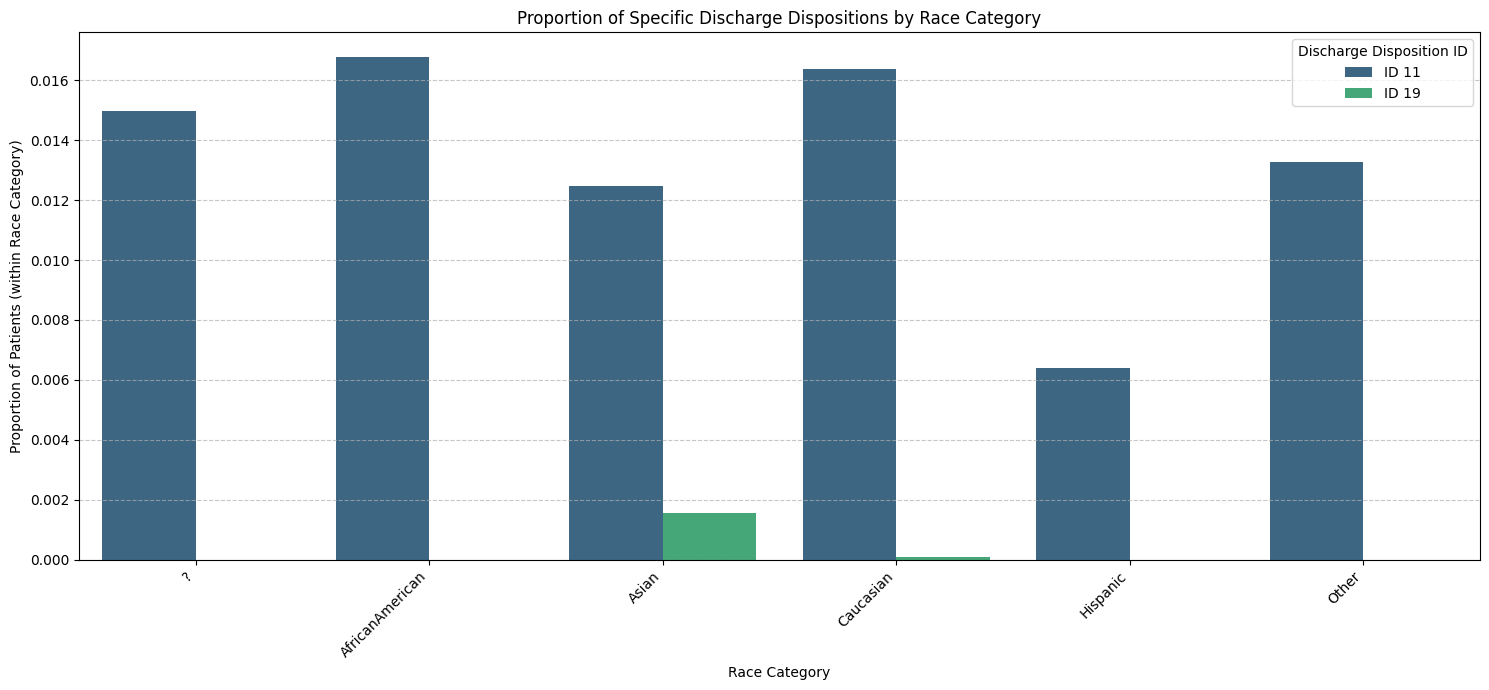

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get all one-hot encoded race columns
race_cols = [col for col in df.columns if col.startswith('race_')]

# Get the specific discharge disposition columns requested by the user that exist in the dataframe
discharge_cols_raw = ['discharge_disposition_id_11', 'discharge_disposition_id_19']
discharge_cols = [col for col in discharge_cols_raw if col in df.columns]

# Select relevant columns for plotting from the main DataFrame `df`
plot_df = df[race_cols + discharge_cols].copy()

# Convert boolean columns to integer (0/1) if they are not already, for summation
for col in plot_df.columns:
    if plot_df[col].dtype == 'bool':
        plot_df[col] = plot_df[col].astype(int)

# Prepare data for plotting: For each discharge disposition, calculate its proportion within each race
data_for_plot = []
for discharge_col in discharge_cols:
    for race_col in race_cols:
        # Count where both race_col is True (1) and discharge_col is True (1)
        count_intersection = plot_df[(plot_df[race_col] == 1) & (plot_df[discharge_col] == 1)].shape[0]
        # Get total for this specific race category
        total_race = plot_df[race_col].sum()

        # Calculate proportion, handle division by zero if a race category has no patients
        proportion = count_intersection / total_race if total_race > 0 else 0

        data_for_plot.append({
            'Discharge Disposition': discharge_col.replace('discharge_disposition_id_', 'ID '), # Clean name for legend
            'Race': race_col.replace('race_', ''), # Clean name for x-axis
            'Proportion': proportion
        })

plot_data = pd.DataFrame(data_for_plot)

# Create the grouped bar plot
plt.figure(figsize=(15, 7))
sns.barplot(
    data=plot_data,
    x='Race',
    y='Proportion',
    hue='Discharge Disposition',
    palette='viridis'
)
plt.title('Proportion of Specific Discharge Dispositions by Race Category')
plt.xlabel('Race Category')
plt.ylabel('Proportion of Patients (within Race Category)')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.legend(title='Discharge Disposition ID')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

LLM based classification with fine tuning.


In [ ]:
# Google Colab drive mounting is not needed when running locally.
# Place the downloaded PDF files in PDF_DIR (the project's data/PDFs/ directory).

# PDF for Readmission disparities

In [16]:
# Install CPU-compatible packages for the local Apple Silicon environment.
# Do not install the CUDA-specific PyTorch build used by the original Windows notebook.
%pip install -q -U torch transformers==4.38.2 faiss-cpu PyMuPDF nltk openai==0.28

  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [1709 lines of output]
      Rust not found, installing into a temporary directory
      Python reports SOABI: cpython-314-darwin
      Computed rustc target triple: aarch64-apple-darwin
      Installation directory: /Users/paydenbullis/Library/Caches/puccinialin
      Rustup already downloaded
      Installing rust to /Users/paydenbullis/Library/Caches/puccinialin/rustup
      warn: It looks like you have an existing rustup settings file at:
      warn: /Users/paydenbullis/Library/Caches/puccinialin/rustup/settings.toml
      warn: Rustup will install the default toolchain as specified in the settings file,
      warn: instead of the one inferred from the default host triple.
      info: profile set to minimal
      info: setting default host triple to aarch64-apple-darwin
      warn: Updating existing toolchain, profile choice will be ignored
  

In [17]:
%pip install nltk


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
%pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.8/30.8 MB 56.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 63.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.1/863.1 kB 40.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20/20 [gradio]19/20 [gradio]]e]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
%pip install openai==0.28


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
%pip install urllib3==1.26.12


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
%pip install requests==2.28.2

  Attempting uninstall: requests
    Found existing installation: requests 2.33.1
    Uninstalling requests-2.33.1:
      Successfully uninstalled requests-2.33.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyterlab-server 2.28.0 requires requests>=2.31, but you have requests 2.28.2 which is incompatible.
datasets 5.0.1 requires requests>=2.32.2, but you have requests 2.28.2 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
%pip install PyMuPDF

import os
import faiss
import fitz  # PyMuPDF
import numpy as np
from transformers import AutoTokenizer, AutoModel
import openai
import torch
import nltk
from nltk.tokenize import sent_tokenize

# Run the RAG embedding pipeline explicitly on CPU using unified memory.
DEVICE = torch.device(COMPUTE_DEVICE)

nltk.download('punkt')

# Step 1: Read PDF Files
def read_pdfs(folder_path):
    pdf_texts = []
    if not os.path.isdir(folder_path):
        raise FileNotFoundError(
            f"The folder does not exist: {folder_path}\n"
            "Please ensure the folder path is correct and accessible in your local PDF directory."
        )

    for file_name in os.listdir(folder_path):
        if file_name.endswith('.pdf'):
            file_path = os.path.join(folder_path, file_name)
            try:
                doc = fitz.open(file_path)
                text = ""
                for page in doc:
                    text += page.get_text()
                pdf_texts.append((file_name, text))
            except Exception as e:
                print(f"Error reading {file_name}: {e}")
    return pdf_texts

# Step 2: Chunk Text
def chunk_text(text, chunk_size=100):
    sentences = sent_tokenize(text)
    chunks = []
    current_chunk = []
    current_length = 0

    for sentence in sentences:
        words = sentence.split()
        if current_length + len(words) > chunk_size:
            chunks.append(' '.join(current_chunk))
            current_chunk = []
            current_length = 0
        current_chunk.extend(words)
        current_length += len(words)

    if current_chunk:
        chunks.append(' '.join(current_chunk))

    return chunks

# Step 3: Create CPU embeddings
def create_embeddings(text_chunks, tokenizer, model):
    embeddings = []
    for chunk in text_chunks:
        inputs = tokenizer(chunk, return_tensors='pt', truncation=True, padding=True, max_length=512)
        inputs = {key: value.to(DEVICE) for key, value in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        embeddings.append(outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy())
    return np.array(embeddings)

# Step 4: Index embeddings with the CPU FAISS implementation
def index_embeddings(embeddings):
    index = faiss.IndexFlatL2(embeddings.shape[1])
    index.add(embeddings)
    return index

# Step 5: Answer questions using OpenAI Chat API
def answer_question_openai_chat(question, all_chunks_list, chunk_source_map, index, embeddings_model, tokenizer, openai_api_key, temperature=1.0, max_tokens=150, top_k=3):
    openai.api_key = openai_api_key

    inputs = tokenizer(question, return_tensors='pt', truncation=True, padding=True, max_length=512)
    inputs = {key: value.to(DEVICE) for key, value in inputs.items()}
    with torch.no_grad():
        question_embedding = embeddings_model(**inputs).last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

    _, indices = index.search(np.array([question_embedding]), k=top_k)
    indices = indices[0]

    retrieved_chunks = []
    sources = set()

    for idx in indices:
        source_name = "Unknown Source"
        source_start_idx = 0
        for src_name, start_idx, end_idx in chunk_source_map:
            if start_idx <= idx <= end_idx:
                source_name = src_name
                source_start_idx = start_idx
                break

        retrieved_chunks.append(all_chunks_list[idx])
        sources.add(f"{source_name}, Chunk {idx - source_start_idx}")

    combined_text = ' '.join(retrieved_chunks)
    messages = [
        {"role": "system", "content": "You are a helpful assistant that is reading a syllabus for a student. Be brief when possible. You don't need to use all the tokens in your response. Always start the response by saying a kind greeting."},
        {"role": "user", "content": f"Context: {combined_text}\n\nQuestion: {question}"}
    ]

    response = openai.ChatCompletion.create(
        model="gpt-3.5-turbo",
        messages=messages,
        max_tokens=max_tokens,
        temperature=temperature,
    )

    refined_answer = response['choices'][0]['message']['content'].strip()
    return f"Answer: {refined_answer}\nSources: {list(sources)}"

# Main function to tie everything together for RAG with both PDFs and CSVs
def main_rag(pdf_folder_path, all_csv_data_formatted, question, model_name, openai_api_key, temperature=1.0, max_tokens=150):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    embeddings_model = AutoModel.from_pretrained(model_name).to(DEVICE)
    embeddings_model.eval()

    pdf_texts_raw = read_pdfs(pdf_folder_path)
    all_document_sources = []

    for pdf_name, text in pdf_texts_raw:
        chunks_for_pdf = chunk_text(text)
        if chunks_for_pdf:
            all_document_sources.append((pdf_name, chunks_for_pdf))

    for csv_file_label, csv_chunks in all_csv_data_formatted:
        if csv_chunks:
            all_document_sources.append((csv_file_label, csv_chunks))

    all_chunks_list = []
    chunk_source_map = []
    current_global_chunk_idx = 0

    for source_name, chunks_from_source in all_document_sources:
        all_chunks_list.extend(chunks_from_source)
        chunk_source_map.append((source_name, current_global_chunk_idx, current_global_chunk_idx + len(chunks_from_source) - 1))
        current_global_chunk_idx += len(chunks_from_source)

    embeddings = create_embeddings(all_chunks_list, tokenizer, embeddings_model)
    index = index_embeddings(embeddings)

    answer = answer_question_openai_chat(
        question=question,
        all_chunks_list=all_chunks_list,
        chunk_source_map=chunk_source_map,
        index=index,
        embeddings_model=embeddings_model,
        tokenizer=tokenizer,
        openai_api_key=openai_api_key,
        temperature=temperature,
        max_tokens=max_tokens
    )
    print(answer)


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1081)>


In [ ]:
%pip install PyMuPDF

In [23]:
import os
import fitz  # PyMuPDF
import numpy as np
import faiss
from transformers import AutoTokenizer, AutoModel
import openai
import torch
import nltk
from nltk.tokenize import sent_tokenize
import gradio as gr

# Local PDF directory configured in the first cell.
folder_path = str(PDF_DIR)

# The function definitions and execution logic below were duplicates of those in cell bOUewfq7TitA
# and were causing conflicts by overwriting the correct implementations.
# Removing them will ensure the intended RAG logic from cell bOUewfq7TitA is active.
# The `main_rag` function (in cell bOUewfq7TitA) will handle reading PDFs and other steps.

In [24]:
import pandas as pd

# Load the local code-reference CSV files from CODES_DIR.
csv_file_path = CODES_DIR / 'Copy of CMS29_DESC_LONG_SHORT_DX 101111u021012.csv'
try:
    codes_df = pd.read_csv(csv_file_path)
    print(f"Successfully loaded {csv_file_path}")
    display(codes_df.head())
except FileNotFoundError:
    print(f"Error: Excel file not found at {csv_file_path}. Please check the path.")
except Exception as e:
    print(f"An error occurred while loading the CSV file: {e}")

csv_admit_file_path = CODES_DIR / 'admission_source_id.csv'
try:
    codes_df = pd.read_csv(csv_admit_file_path)
    print(f"Successfully loaded {csv_admit_file_path}")
    display(codes_df.head())
except FileNotFoundError:
    print(f"CSV file not found at {csv_admit_file_path}. Please check the local data directory.")
except Exception as e:
    print(f"An error occurred while loading the CSV file: {e}")

csv_admit_type_file_path = CODES_DIR / 'admission_type_id.csv'
try:
    codes_df = pd.read_csv(csv_admit_type_file_path)
    print(f"Successfully loaded {csv_admit_type_file_path}")
    display(codes_df.head())
except FileNotFoundError:
    print(f"CSV file not found at {csv_admit_type_file_path}. Please check the local data directory.")
except Exception as e:
    print(f"An error occurred while loading the CSV file: {e}")

csv_file_discharge_path = CODES_DIR / 'discharge_disposition_id.csv'
try:
    codes_df = pd.read_csv(csv_file_discharge_path)
    print(f"Successfully loaded {csv_file_discharge_path}")
    display(codes_df.head())
except FileNotFoundError:
    print(f"CSV file not found at {csv_file_discharge_path}. Please check the local data directory.")
except Exception as e:
    print(f"An error occurred while loading the CSV file: {e}")

Successfully loaded Codes/Copy of CMS29_DESC_LONG_SHORT_DX 101111u021012.csv


,DIAGNOSIS CODE,LONG DESCRIPTION,SHORT DESCRIPTION,Unnamed: 3
0,0010,Cholera due to vibrio cholerae,Cholera d/t vib cholerae,NaN
1,0011,Cholera due to vibrio cholerae el tor,Cholera d/t vib el tor,NaN
2,0019,"Cholera, unspecified",Cholera NOS,NaN
3,0020,Typhoid fever,Typhoid fever,NaN
4,0021,Paratyphoid fever A,Paratyphoid fever a,NaN


Successfully loaded Codes/admission_source_id.csv


,admission source,description
0,1,Physician Referral
1,2,Clinic Referral
2,3,HMO Referral
3,4,Transfer from a hospital
4,5,Transfer from a Skilled Nursing Facility (SNF)


Successfully loaded Codes/admission_type_id.csv


,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available


Successfully loaded Codes/discharge_disposition_id.csv


,discharge_disposition_id,description
0,1,Discharged to home
1,2,Discharged/transferred to another short term h...
2,3,Discharged/transferred to SNF
3,4,Discharged/transferred to ICF
4,5,Discharged/transferred to another type of inpa...


In [26]:
import pandas as pd

# Path to the local admission-source reference CSV.
problematic_csv_path = CODES_DIR / 'admission_source_id.csv'

try:
    # Load the CSV file
    debug_df = pd.read_csv(problematic_csv_path)
    print(f"Successfully loaded {problematic_csv_path}")

    # Display basic information
    print("\nDataFrame Head:")
    display(debug_df.head())

    print("\nDataFrame Info:")
    debug_df.info()

    print("\nNull Value Counts:")
    display(debug_df.isnull().sum())

    # Attempt to generate text chunks from this debug DataFrame with the specified columns
    debug_text_chunks = []
    code_col = 'admission_source_id'
    name_col = 'description'
    file_label = 'admission_source.csv'

    for index, row in debug_df.iterrows():
        code_str = str(row.get(code_col, ''))
        name_str = str(row.get(name_col, ''))

        # Print raw values to see what's being retrieved
        # print(f"Row {index}: code_raw='{row.get(code_col)}', name_raw='{row.get(name_col)}'")
        # print(f"Row {index}: code_str='{code_str}', name_str='{name_str}'")

        if code_str.strip() and name_str.strip(): # Use .strip() to check for non-whitespace content
            debug_text_chunks.append(f"{file_label.replace('_', ' ').replace('.csv', '')} Code: {code_str}, Name: {name_str}")

    if debug_text_chunks:
        print(f"\nSuccessfully generated {len(debug_text_chunks)} debug entries.")
        print("First 5 debug entries:")
        for entry in debug_text_chunks[:5]:
            print(f"- {entry}")
    else:
        print("\nNo valid debug entries could be generated from admission_source_id.csv with current logic.")

except FileNotFoundError:
    print(f"CSV file not found at {problematic_csv_path}. Please check the local data directory.")
except Exception as e:
    print(f"An error occurred while loading or processing {problematic_csv_path}: {e}")

Successfully loaded Codes/admission_source_id.csv

DataFrame Head:


,admission source,description
0,1,Physician Referral
1,2,Clinic Referral
2,3,HMO Referral
3,4,Transfer from a hospital
4,5,Transfer from a Skilled Nursing Facility (SNF)



DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   admission source  25 non-null     int64
 1   description       24 non-null     str  
dtypes: int64(1), str(1)
memory usage: 1.1 KB

Null Value Counts:


admission source    0
description         1
dtype: int64


No valid debug entries could be generated from admission_source_id.csv with current logic.


In [27]:
import pandas as pd

# Define the paths to your CSV files
csv_files_info = [
    {
        'path': CODES_DIR / 'Copy of CMS29_DESC_LONG_SHORT_DX 101111u021012.csv',
        'code_col': 'DIAGNOSIS CODE',
        'name_col': 'LONG DESCRIPTION',
        'file_label': 'diagnosis_codes.csv'
    },
    {
        'path': CODES_DIR / 'admission_source_id.csv',
        'code_col': 'admission source',
        'name_col': 'description',
        'file_label': 'admission_source.csv'
    },
    {
        'path': CODES_DIR / 'admission_type_id.csv',
        'code_col': 'admission_type_id',
        'name_col': 'description',
        'file_label': 'admission_type.csv'
    },
    {
        'path': CODES_DIR / 'discharge_disposition_id.csv',
        'code_col': 'discharge_disposition_id',
        'name_col': 'description',
        'file_label': 'discharge_disposition.csv'
    }
]

all_csv_data_formatted = []
total_entries_processed = 0

print("--- Processing CSV files ---")

for file_info in csv_files_info:
    file_path = file_info['path']
    code_col = file_info['code_col']
    name_col = file_info['name_col']
    file_label = file_info['file_label']

    try:
        current_df = pd.read_csv(file_path)
        print(f"Successfully loaded {file_label} from {file_path}")

        current_text_chunks = []
        for index, row in current_df.iterrows():
            code_str = str(row.get(code_col, '')).strip() # Added .strip() for robustness
            name_str = str(row.get(name_col, '')).strip() # Added .strip() for robustness
            if code_str and name_str:
                current_text_chunks.append(f"{file_label.replace('_', ' ').replace('.csv', '')} Code: {code_str}, Name: {name_str}")

        if current_text_chunks:
            all_csv_data_formatted.append((file_label, current_text_chunks))
            total_entries_processed += len(current_text_chunks)
            print(f"Prepared {len(current_text_chunks)} entries from {file_label}.")
            print(f"First 3 formatted entries from {file_label}:")
            for i, entry in enumerate(current_text_chunks[:3]):
                print(f"- {entry}")
        else:
            print(f"No valid code-name entries found in {file_label}.")

    except FileNotFoundError:
        print(f"Error: CSV file not found at {file_path}. Please check the path.")
    except Exception as e:
        print(f"An error occurred while loading or processing {file_label}: {e}")

print("\n--- Summary ---")
print(f"Total prepared entries from all CSVs: {total_entries_processed}")

--- Processing CSV files ---
Successfully loaded diagnosis_codes.csv from Codes/Copy of CMS29_DESC_LONG_SHORT_DX 101111u021012.csv
Prepared 14567 entries from diagnosis_codes.csv.
First 3 formatted entries from diagnosis_codes.csv:
- diagnosis codes Code: 0010, Name: Cholera due to vibrio cholerae
- diagnosis codes Code: 0011, Name: Cholera due to vibrio cholerae el tor
- diagnosis codes Code: 0019, Name: Cholera, unspecified
Successfully loaded admission_source.csv from Codes/admission_source_id.csv
Prepared 25 entries from admission_source.csv.
First 3 formatted entries from admission_source.csv:
- admission source Code: 1, Name: Physician Referral
- admission source Code: 2, Name: Clinic Referral
- admission source Code: 3, Name: HMO Referral
Successfully loaded admission_type.csv from Codes/admission_type_id.csv
Prepared 8 entries from admission_type.csv.
First 3 formatted entries from admission_type.csv:
- admission type Code: 1, Name: Emergency
- admission type Code: 2, Name: Urg

#Theres an App for that


In [28]:
%pip install -q gradio
import gradio as gr


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [41]:
import json
import math
import openai
import pandas as pd
import numpy as np
import re
import traceback
import os

# Read the key from the local environment; never place the key in this notebook.
openai.api_key = os.environ.get('OPENAI_API_KEY')
if not openai.api_key:
    print("Warning: OPENAI_API_KEY is not set. Add it to your environment before using the app.")

# Ensure the XGBoost model and feature list are available from earlier cells.

# Extraction function using LLM
def extract_features_from_notes(notes):
    prompt = f"""
    You are a medical data extractor. Extract the following features from the clinical notes below.
    Return ONLY a valid JSON object with the exact keys. If a feature is not mentioned, use sensible defaults (0 for boolean/counts).
    Keys to extract: {existing_xgb_features}

    Important Discharge Disposition Context:
    - ID 1: Discharged to home
    - ID 11: Expired (deceased)
    - ID 19: Expired at home
    - ID 20: Expired in a medical facility
    Ensure if the notes state the patient expired or is deceased, the corresponding feature (e.g., discharge_disposition_id_11) is set to 1.

    Clinical Notes:
    {notes}
    """
    raw_response = ""
    try:
        response = openai.ChatCompletion.create(
            model="gpt-3.5-turbo",
            messages=[{"role": "system", "content": "You return strictly JSON."},
                      {"role": "user", "content": prompt}],
            temperature=0.0
        )
        raw_response = response['choices'][0]['message']['content'].strip()

        # Clean up markdown code blocks if the LLM adds them
        extracted_json = re.sub(r"^```json\s*", "", raw_response)
        extracted_json = re.sub(r"^```\s*", "", extracted_json)
        extracted_json = re.sub(r"\s*```$", "", extracted_json)
        extracted_json = extracted_json.strip()

        features_dict = json.loads(extracted_json)

        # Ensure all required features are present
        df_input = pd.DataFrame([features_dict])
        for col in existing_xgb_features:
            if col not in df_input.columns:
                df_input[col] = 0

        df_input = df_input[existing_xgb_features]
        return df_input, "Success"
    except Exception as e:
        error_trace = traceback.format_exc()
        error_msg = f"Exception: {str(e)}\n\nRaw LLM Response:\n{raw_response}\n\nTraceback:\n{error_trace}"
        return None, error_msg

# Prediction function
def predict_risk(df_input):
    try:
        # Sanitize column names to match the XGBoost training data
        def sanitize_colnames(df):
            cols = df.columns
            new_cols = []
            for col in cols:
                new_col = re.sub(r'[^a-zA-Z0-9_]', '_', col)
                new_cols.append(new_col)
            df.columns = new_cols
            return df

        df_input_sanitized = sanitize_colnames(df_input.copy())

        # Using the weighted xgb_model from memory
        proba_weighted = xgb_model.predict_proba(df_input_sanitized)[0][1]

        # Calculate Log Odds
        log_odds_weighted = math.log(proba_weighted / (1 - proba_weighted)) if 0 < proba_weighted < 1 else 0

        prediction = "Readmission (<30 days)" if proba_weighted >= 0.5 else "No Readmission"

        result_text = f"Weighted XGBoost Prediction: {prediction}\n"
        result_text += f"Probability: {proba_weighted:.4f}\n"
        result_text += f"Log Odds: {log_odds_weighted:.4f}\n"

        return result_text, proba_weighted
    except Exception as e:
        return f"Prediction Error:\n{traceback.format_exc()}", None

# Recommendation function using RAG
def generate_recommendation(notes, risk_score, df_extracted=None):
    if risk_score is None:
        return "Cannot generate recommendation without a valid risk score."

    # Early exit if patient has expired
    if df_extracted is not None:
        deceased_cols = ['discharge_disposition_id_11', 'discharge_disposition_id_19', 'discharge_disposition_id_20']
        for col in deceased_cols:
            if col in df_extracted.columns and df_extracted[col].iloc[0] == 1:
                return "Patient has expired (deceased). No follow-up or readmission prevention recommendations are applicable."

    question = f"The patient has a readmission risk score of {risk_score:.2f}. Based on their clinical notes: '{notes}', and the disparities guidelines in the PDF and diagnosis codes, what are the recommended follow-ups?"

    try:
        response = openai.ChatCompletion.create(
            model="gpt-3.5-turbo",
            messages=[
                {"role": "system", "content": "You are a helpful medical assistant providing follow-up recommendations based on patient risk and guidelines."},
                {"role": "user", "content": question}
            ],
            temperature=0.2
        )
        return response['choices'][0]['message']['content'].strip()
    except Exception as e:
        return f"Recommendation Error:\n{traceback.format_exc()}"

# Gradio Interface wrapper
def process_patient_notes(notes):
    # 1. Extract
    df_extracted, extraction_status = extract_features_from_notes(notes)
    if df_extracted is None:
        return {"error": "Extraction failed"}, f"Extraction Error Log:\n{extraction_status}", "Extraction failed. See prediction field for errors."

    # 2. Predict
    prediction_results, proba = predict_risk(df_extracted)
    if proba is None:
        return df_extracted.to_dict(orient='records')[0], prediction_results, "Prediction failed."

    # 3. Recommend (pass df_extracted so we can check for expired disposition)
    recommendations = generate_recommendation(notes, proba, df_extracted)

    # Convert DataFrame to a dict record so Gradio JSON component parses it easily
    extracted_dict = df_extracted.to_dict(orient='records')[0]

    return extracted_dict, prediction_results, recommendations

# Build Gradio App
with gr.Blocks(title="Diabetic Patient Readmission Risk & Recommendation") as app:
    gr.Markdown("## 🏥 Diabetic Patient Readmission Risk Predictor")
    gr.Markdown("Enter patient notes below. The app will extract features, predict readmission risk (log odds), and provide recommendations.")

    with gr.Row():
        with gr.Column():
            notes_input = gr.Textbox(lines=10, label="Medical Professional Notes", placeholder="Enter clinical notes...")
            submit_btn = gr.Button("Process Notes & Predict")

        with gr.Column():
            extracted_output = gr.JSON(label="Extracted Features (JSON) / Error Dict")
            prediction_output = gr.Textbox(label="Prediction & Log Odds (Weighted XGBoost) / Error Log", lines=10)
            recommendation_output = gr.Textbox(lines=8, label="Follow-up Recommendations")

    submit_btn.click(fn=process_patient_notes, inputs=notes_input, outputs=[extracted_output, prediction_output, recommendation_output])

app.launch(debug=True, share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://bd439ba4ae63cd8285.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://bd439ba4ae63cd8285.gradio.live


In [40]:
import json

# 1. Save the trained XGBoost model to a file
xgb_model.save_model("xgb_model.json")
print("Model saved to 'xgb_model.json'")

# 2. Create the requirements.txt file
with open("requirements.txt", "w") as f:
    f.write("gradio\npandas\nxgboost\nopenai==0.28.0\n")
print("Dependencies saved to 'requirements.txt'")

# 3. Create the standalone app.py script
app_code = """import gradio as gr
import pandas as pd
import xgboost as xgb
import openai
import os
import json
import math
import re
import traceback

# Get OpenAI key from environment variables (configured in HF Space Secrets)
openai.api_key = os.environ.get("OPENAI_API_KEY")

# Load the trained model
xgb_model = xgb.XGBClassifier()
xgb_model.load_model('xgb_model.json')

# Hardcoded features from your notebook training
existing_xgb_features = __FEATURES_LIST__

# Extraction function using LLM
def extract_features_from_notes(notes):
    prompt = f'''
    You are a medical data extractor. Extract the following features from the clinical notes below.
    Return ONLY a valid JSON object with the exact keys. If a feature is not mentioned, use sensible defaults (0 for boolean/counts).
    Keys to extract: {existing_xgb_features}

    Important Discharge Disposition Context:
    - ID 1: Discharged to home
    - ID 11: Expired (deceased)
    - ID 19: Expired at home
    - ID 20: Expired in a medical facility
    Ensure if the notes state the patient expired or is deceased, the corresponding feature (e.g., discharge_disposition_id_11) is set to 1.

    Clinical Notes:
    {notes}
    '''
    raw_response = ""
    try:
        response = openai.ChatCompletion.create(
            model="gpt-3.5-turbo",
            messages=[{"role": "system", "content": "You return strictly JSON."},
                      {"role": "user", "content": prompt}],
            temperature=0.0
        )
        raw_response = response['choices'][0]['message']['content'].strip()

        extracted_json = re.sub(r"^```json\s*", "", raw_response)
        extracted_json = re.sub(r"^```\s*", "", extracted_json)
        extracted_json = re.sub(r"\s*```$", "", extracted_json)
        extracted_json = extracted_json.strip()

        features_dict = json.loads(extracted_json)

        df_input = pd.DataFrame([features_dict])
        for col in existing_xgb_features:
            if col not in df_input.columns:
                df_input[col] = 0

        df_input = df_input[existing_xgb_features]
        return df_input, "Success"
    except Exception as e:
        return None, f"Exception: {str(e)}\n\nRaw Response:\n{raw_response}"

# Prediction function
def predict_risk(df_input):
    try:
        def sanitize_colnames(df):
            cols = df.columns
            new_cols = []
            for col in cols:
                new_col = re.sub(r'[^a-zA-Z0-9_]', '_', col)
                new_cols.append(new_col)
            df.columns = new_cols
            return df

        df_input_sanitized = sanitize_colnames(df_input.copy())
        proba_weighted = xgb_model.predict_proba(df_input_sanitized)[0][1]
        log_odds_weighted = math.log(proba_weighted / (1 - proba_weighted)) if 0 < proba_weighted < 1 else 0
        prediction = "Readmission (<30 days)" if proba_weighted >= 0.5 else "No Readmission"

        result_text = f"Weighted XGBoost Prediction: {prediction}\n"
        result_text += f"Probability: {proba_weighted:.4f}\n"
        result_text += f"Log Odds: {log_odds_weighted:.4f}\n"
        return result_text, proba_weighted
    except Exception as e:
        return f"Prediction Error:\n{traceback.format_exc()}", None

# Recommendation function using LLM
def generate_recommendation(notes, risk_score, df_extracted=None):
    if risk_score is None:
        return "Cannot generate recommendation without a valid risk score."

    if df_extracted is not None:
        deceased_cols = ['discharge_disposition_id_11', 'discharge_disposition_id_19', 'discharge_disposition_id_20']
        for col in deceased_cols:
            if col in df_extracted.columns and df_extracted[col].iloc[0] == 1:
                return "Patient has expired (deceased). No follow-up or readmission prevention recommendations are applicable."

    question = f"The patient has a readmission risk score of {risk_score:.2f}. Based on their clinical notes: '{notes}', and the disparities guidelines in the PDF and diagnosis codes, what are the recommended follow-ups?"

    try:
        response = openai.ChatCompletion.create(
            model="gpt-3.5-turbo",
            messages=[
                {"role": "system", "content": "You are a helpful medical assistant providing follow-up recommendations based on patient risk and guidelines."},
                {"role": "user", "content": question}
            ],
            temperature=0.2
        )
        return response['choices'][0]['message']['content'].strip()
    except Exception as e:
        return f"Recommendation Error:\n{traceback.format_exc()}"

# Gradio Interface wrapper
def process_patient_notes(notes):
    df_extracted, extraction_status = extract_features_from_notes(notes)
    if df_extracted is None:
        return {"error": "Extraction failed"}, f"Extraction Error Log:\n{extraction_status}", "Extraction failed."

    prediction_results, proba = predict_risk(df_extracted)
    if proba is None:
        return df_extracted.to_dict(orient='records')[0], prediction_results, "Prediction failed."

    recommendations = generate_recommendation(notes, proba, df_extracted)
    extracted_dict = df_extracted.to_dict(orient='records')[0]

    return extracted_dict, prediction_results, recommendations

# Build Gradio App
with gr.Blocks(title="Diabetic Patient Readmission Risk & Recommendation") as app:
    gr.Markdown("## 🏥 Diabetic Patient Readmission Risk Predictor")
    gr.Markdown("Enter patient notes below. The app will extract features, predict readmission risk (log odds), and provide recommendations.")

    with gr.Row():
        with gr.Column():
            notes_input = gr.Textbox(lines=10, label="Medical Professional Notes", placeholder="E.g., 65-year-old African American patient...")
            submit_btn = gr.Button("Process Notes & Predict")

        with gr.Column():
            extracted_output = gr.JSON(label="Extracted Features (JSON) / Error Dict")
            prediction_output = gr.Textbox(label="Prediction & Log Odds (Weighted XGBoost)", lines=10)
            recommendation_output = gr.Textbox(lines=8, label="Follow-up Recommendations")

    submit_btn.click(fn=process_patient_notes, inputs=notes_input, outputs=[extracted_output, prediction_output, recommendation_output])

if __name__ == "__main__":
    app.launch()
"""

# Inject the features list dynamically into the string
app_code = app_code.replace("__FEATURES_LIST__", str(existing_xgb_features))

with open("app.py", "w") as f:
    f.write(app_code)
print("App script saved to 'app.py'")
print("\nSuccess! You can now download `xgb_model.json`, `app.py`, and `requirements.txt` from the Files panel.")

Model saved to 'xgb_model.json'
Dependencies saved to 'requirements.txt'
App script saved to 'app.py'

Success! You can now download `xgb_model.json`, `app.py`, and `requirements.txt` from the Files panel.


<>:60: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:60: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/_b/2m57r1t17tl3v1hgdpbgsl_00000gn/T/ipykernel_13129/149233569.py:60: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  extracted_json = re.sub(r"^```json\s*", "", raw_response)
